# Experiment A — YOLO Pose MPJPE and PCK vs Network Period

This notebook evaluates the **YOLO Pose** Experiment A outputs generated by
`YOLO_run_experiment_a.sh` on the **eH36M S9/S11 RGB test set**.

It reproduces the EventPointPose analysis:

- per-sequence and dataset-level **MPJPE**
- dataset-level MPJPE population standard deviation
- normalized **PCK** at multiple thresholds
- per-joint MPJPE and PCK
- plots against requested network inference rate
- optional GT-versus-prediction traces

It also evaluates inference latency and the output rate actually observed in the
prediction timestamps. This detects runs in which the requested
`network_period` was not applied.

Expected layout:

```text
h36m_full_test/results/raw/
└── np_<period>/
    └── <sequence>_yolopose_np_<period>.csv
```


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from datasets.utils import constants as ds_constants, parsing as ds_parsing

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
})
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Configuration

The default experiment directory matches the YOLO entry used in the Experiment
A comparison notebook.


In [2]:
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
EXP_DATASET_DIR = DATA_DIR / 'moveEnetOFK/YOLO_h36m_full_test'
EXP_DIR = EXP_DATASET_DIR

RGB_DATA_ROOT = DATA_DIR / 'eh36m_testing_set_S9S11/rgb'
GT_DATA_ROOT = DATA_DIR / 'eh36m_testing_set_S9S11/events'

RAW_DIR = EXP_DATASET_DIR / 'results' / 'raw'
AUTO_FALLBACK_RAW_DIRS = [EXP_DIR / 'results' / 'raw']

SUMMARY_DIR = EXP_DATASET_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DATASET_DIR / 'plots'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_NETWORK_PERIODS = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
PCK_THRESHOLDS = [0.1, 0.2, 0.4, 0.6]

# Same PCK normalization used in the EPP/MoveEnet notebooks.
REF_JOINT_1 = 1
REF_JOINT_2 = 5

DATASET_FPS = 50.0
ZERO_POSE_IS_MISSING = True
RATE_TOLERANCE_FRACTION = 0.25
COORD_LIMIT = 1e6
MAX_FILES = None

CORRUPTED_EH36M_GT_FILES = [
    'cam4_S11_Greeting/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Eating/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Greeting/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Photo/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Photo_1/ch0GT50Hzskeleton/data.log',
    'cam4_S9_SittingDown_1/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Waiting_1/ch0GT50Hzskeleton/data.log',
    'Cam4_S9_Walking/ch0GT50Hzskeleton/data.log',
]
CORRUPTED_EH36M_SEQUENCES = {
    Path(path).parts[0].lower()
    for path in CORRUPTED_EH36M_GT_FILES
}

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

print('RAW_DIR:', RAW_DIR)
print('GT_DATA_ROOT:', GT_DATA_ROOT)
print('Expected periods:', EXPECTED_NETWORK_PERIODS)
print('PCK thresholds:', PCK_THRESHOLDS)
print(
    f'PCK reference: {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) to '
    f'{REF_JOINT_2} ({joint_names[REF_JOINT_2]})'
)


RAW_DIR: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/results/raw
GT_DATA_ROOT: /data/eh36m_testing_set_S9S11/events
Expected periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
PCK thresholds: [0.1, 0.2, 0.4, 0.6]
PCK reference: 1 (shoulder_right) to 5 (hip_left)


## Utility functions


In [3]:
PERIOD_PATTERN = r'(?:\d+p\d+|\d+)'


def resolve_raw_dir(raw_dir: Path, fallback_dirs):
    if raw_dir.exists():
        return raw_dir
    for fallback in fallback_dirs:
        if fallback.exists():
            print(f'RAW_DIR not found, using: {fallback}')
            return fallback
    raise FileNotFoundError(
        f'Could not find RAW_DIR={raw_dir} or any fallback directory.'
    )


def tag_to_period(tag: str) -> float:
    return float(str(tag).strip().replace('p', '.'))


def normalize_csv_name(csv_path: Path) -> str:
    name = csv_path.name.strip()
    return re.sub(r'\s+\.csv$', '.csv', name)


def period_from_folder(csv_path: Path) -> float:
    folder = csv_path.parent.name.strip()
    if not folder.startswith('np_'):
        raise ValueError(f'Unexpected period folder: {folder}')
    return tag_to_period(folder.replace('np_', '', 1))


def is_empty_prediction_csv(csv_path: Path) -> bool:
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        return True
    with csv_path.open('r', encoding='utf-8', errors='ignore') as stream:
        return sum(1 for line in stream if line.strip()) <= 1


def extract_metadata_from_name(csv_path: Path):
    """
    Parse:
        <sequence>_yolopose_np_<period>.csv
    """
    match = re.fullmatch(
        rf'(?P<sequence>.+?)_yolopose_np_'
        rf'(?P<period>{PERIOD_PATTERN})\.csv',
        normalize_csv_name(csv_path),
        flags=re.IGNORECASE,
    )
    if match is None:
        raise ValueError(f'Unrecognized YOLO Pose filename: {csv_path.name}')
    return match.group('sequence'), tag_to_period(match.group('period'))


def gt_path_from_sequence(sequence: str) -> Path:
    return (
        GT_DATA_ROOT
        / sequence
        / 'ch0GT200Hzskeleton'
        / 'data.log'
    )


def load_prediction_csv(csv_path: Path):
    """
    Return timestamp [N], latency [N], and joints [N, 13, 2].
    """
    frame = pd.read_csv(csv_path)
    frame.columns = [str(column).strip() for column in frame.columns]

    joint_columns = []
    for joint_index in range(13):
        joint_columns.extend([
            f'joint{joint_index}_x',
            f'joint{joint_index}_y',
        ])

    required = ['timestamp', 'latency'] + joint_columns
    missing = [column for column in required if column not in frame.columns]
    if missing:
        raise ValueError(f'Missing columns in {csv_path}: {missing}')
    if frame.empty:
        raise ValueError(f'Empty CSV: {csv_path}')

    timestamps = frame['timestamp'].to_numpy(dtype=float)
    latency = frame['latency'].to_numpy(dtype=float)
    joints = (
        frame[joint_columns]
        .to_numpy(dtype=float)
        .reshape(-1, 13, 2)
    )

    order = np.argsort(timestamps, kind='stable')
    return timestamps[order], latency[order], joints[order]


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray) -> np.ndarray:
    """
    Interpolate eH36M ground truth to prediction timestamps.
    """
    ts_gt_raw = np.asarray(gt_data['ts'], dtype=float)
    if ts_gt_raw.size == 0:
        raise ValueError('Ground-truth file has no timestamps')

    # Preserve the convention used in the existing experiment notebooks.
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=float)

    for joint_index, joint_name in enumerate(joint_names):
        values = np.asarray(gt_data[joint_name], dtype=float)
        x_raw = values[:, 0]
        y_raw = values[:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, joint_index, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, joint_index, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt


def invalid_joint_points(joints: np.ndarray) -> np.ndarray:
    return (
        ~np.isfinite(joints).all(axis=2)
        | (np.abs(joints) > COORD_LIMIT).any(axis=2)
    )


def calculate_pck_binary(joints_pred, joints_gt, threshold):
    error = np.linalg.norm(joints_pred - joints_gt, axis=2)
    reference = (
        joints_gt[:, REF_JOINT_2, :]
        - joints_gt[:, REF_JOINT_1, :]
    )
    reference_distance = np.linalg.norm(reference, axis=1)
    reference_distance = np.maximum(reference_distance, 1e-6)
    return (
        error <= threshold * reference_distance[:, None]
    ).astype(np.float32)


def timing_statistics(timestamps, network_period_s):
    unique_ts = np.unique(np.asarray(timestamps, dtype=float))
    positive_dt = np.diff(unique_ts)
    positive_dt = positive_dt[positive_dt > 0]

    target_rate_hz = min(DATASET_FPS, 1.0 / network_period_s)
    target_period_s = 1.0 / target_rate_hz

    if positive_dt.size:
        observed_period_s = float(np.median(positive_dt))
        observed_rate_hz = float(1.0 / observed_period_s)
        prediction_span_s = float(unique_ts[-1] - unique_ts[0])
        n_intervals = int(positive_dt.size)
        relative_error = abs(observed_rate_hz - target_rate_hz) / target_rate_hz
        matches = relative_error <= RATE_TOLERANCE_FRACTION
    else:
        observed_period_s = np.nan
        observed_rate_hz = np.nan
        prediction_span_s = 0.0
        n_intervals = 0
        relative_error = np.nan
        matches = False

    return {
        'target_output_period_s': target_period_s,
        'target_output_rate_hz': target_rate_hz,
        'observed_output_period_s': observed_period_s,
        'observed_output_rate_hz': observed_rate_hz,
        'relative_rate_error': relative_error,
        'rate_matches_request': bool(matches),
        'prediction_span_s': prediction_span_s,
        'n_intervals': n_intervals,
    }


def set_actual_x_ticks(ax, values):
    ticks = sorted(pd.Series(values).dropna().unique())
    if not ticks:
        return
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{value:g}' for value in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def plot_metric(
    table,
    y_col,
    ylabel,
    title,
    output_path,
    yerr_col=None,
    reference_y_col=None,
    ylim=None,
):
    data = table.sort_values('detection_rate_hz')
    fig, ax = plt.subplots(figsize=(8, 5))

    if yerr_col is not None:
        ax.errorbar(
            data['detection_rate_hz'],
            data[y_col],
            yerr=data[yerr_col],
            marker='o',
            capsize=4,
            label='YOLO Pose',
        )
    else:
        ax.plot(
            data['detection_rate_hz'],
            data[y_col],
            marker='o',
            label='YOLO Pose',
        )

    if reference_y_col is not None:
        ax.plot(
            data['detection_rate_hz'],
            data[reference_y_col],
            marker='x',
            linestyle='--',
            label='Requested/target',
        )

    ax.set_xscale('log')
    set_actual_x_ticks(ax, data['detection_rate_hz'])
    ax.set_xlabel('Requested network inference rate (Hz)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)


## Discover prediction CSV files

The period in each filename is checked against the enclosing `np_*` directory.
Known corrupted eH36M sequences and empty CSVs are excluded.


In [4]:
RAW_DIR = resolve_raw_dir(RAW_DIR, AUTO_FALLBACK_RAW_DIRS)
csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))

if MAX_FILES is not None:
    csv_files = csv_files[:MAX_FILES]

if not csv_files:
    raise RuntimeError(
        'No files found in RAW_DIR/np_*/*.csv. Check RAW_DIR.'
    )

records = []
skipped = []
parse_errors = []

for csv_path in csv_files:
    try:
        sequence, period = extract_metadata_from_name(csv_path)
        folder_period = period_from_folder(csv_path)
        if not np.isclose(period, folder_period):
            raise ValueError(
                f'Period mismatch: filename={period}, folder={folder_period}'
            )

        reason = ''
        if sequence.lower() in CORRUPTED_EH36M_SEQUENCES:
            reason = 'known corrupted eH36M GT sequence'
        elif is_empty_prediction_csv(csv_path):
            reason = 'empty/header-only CSV'

        row = {
            'csv_path': csv_path,
            'sequence': sequence,
            'network_period_s': period,
            'detection_rate_hz': 1.0 / period,
            'skip_reason': reason,
        }
        (skipped if reason else records).append(row)

    except Exception as exc:
        parse_errors.append({
            'csv_path': str(csv_path),
            'error': repr(exc),
        })

df_files = pd.DataFrame(records)
df_skipped = pd.DataFrame(skipped)
df_parse_errors = pd.DataFrame(parse_errors)

print('Candidate CSVs:', len(csv_files))
print('Usable CSVs:', len(df_files))
print('Skipped CSVs:', len(df_skipped))
print('Parse errors:', len(df_parse_errors))

if len(df_parse_errors):
    display(df_parse_errors.head(20))
if len(df_skipped):
    display(df_skipped.head(20))
if df_files.empty:
    raise RuntimeError('No usable YOLO Pose CSV files remain.')

df_files = (
    df_files
    .sort_values(['network_period_s', 'sequence'])
    .reset_index(drop=True)
)

discovery_summary = (
    df_files
    .groupby(['network_period_s', 'detection_rate_hz'], as_index=False)
    .agg(n_csv=('sequence', 'size'), n_sequences=('sequence', 'nunique'))
    .sort_values('network_period_s')
)
display(discovery_summary)

discovered_periods = sorted(df_files['network_period_s'].unique())
missing_periods = [
    expected
    for expected in EXPECTED_NETWORK_PERIODS
    if not any(np.isclose(expected, found) for found in discovered_periods)
]
print('Discovered periods:', discovered_periods)
if missing_periods:
    print('Warning: missing expected periods:', missing_periods)


Candidate CSVs: 595
Usable CSVs: 468
Skipped CSVs: 127
Parse errors: 0


,csv_path,sequence,network_period_s,detection_rate_hz,skip_reason
0,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S11_SittingDown,0.02,50.0,empty/header-only CSV
1,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S9_Photo_1,0.02,50.0,empty/header-only CSV
2,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S9_Purchases_1,0.02,50.0,empty/header-only CSV
3,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S11_Eating,0.02,50.0,empty/header-only CSV
4,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S11_Greeting,0.02,50.0,known corrupted eH36M GT sequence
5,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S11_Purchases_1,0.02,50.0,empty/header-only CSV
6,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Eating_1,0.02,50.0,empty/header-only CSV
7,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Eating,0.02,50.0,known corrupted eH36M GT sequence
8,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Greeting,0.02,50.0,known corrupted eH36M GT sequence
9,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Photo_1,0.02,50.0,known corrupted eH36M GT sequence


,network_period_s,detection_rate_hz,n_csv,n_sequences
0,0.02,50.0,104,104
1,0.05,20.0,99,99
2,0.10,10.0,105,105
3,0.20,5.0,90,90
4,0.50,2.0,70,70


Discovered periods: [0.02, 0.05, 0.1, 0.2, 0.5]


## Compute per-sequence metrics

Invalid rows and completely zero skeletons are removed. Sums and counts are
stored so the dataset-level aggregation remains exactly weighted.


In [5]:
gt_cache = {}
rows = []
missing_gt = []
evaluation_errors = []

for index, rec in enumerate(df_files.to_dict('records'), start=1):
    if index == 1 or index % 50 == 0 or index == len(df_files):
        print(f'[{index}/{len(df_files)}]')

    csv_path = Path(rec['csv_path'])
    sequence = rec['sequence']
    period = float(rec['network_period_s'])
    gt_path = gt_path_from_sequence(sequence)

    if not gt_path.exists():
        missing_gt.append({
            'sequence': sequence,
            'network_period_s': period,
            'gt_path': str(gt_path),
        })
        continue

    try:
        if gt_path not in gt_cache:
            gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
                gt_path,
                multi_channel=False,
            )

        gt_data = gt_cache[gt_path]
        ts_pred, latency_s, joints_pred = load_prediction_csv(csv_path)
        joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

        valid = (
            np.isfinite(ts_pred)
            & np.isfinite(latency_s)
            & ~invalid_joint_points(joints_pred).any(axis=1)
            & ~invalid_joint_points(joints_gt).any(axis=1)
        )
        if ZERO_POSE_IS_MISSING:
            valid &= np.any(np.abs(joints_pred) > 1e-9, axis=(1, 2))

        if not valid.any():
            raise ValueError('No valid prediction rows after filtering')

        ts_pred = ts_pred[valid]
        latency_s = latency_s[valid]
        joints_pred = joints_pred[valid]
        joints_gt = joints_gt[valid]

        error_px = np.linalg.norm(joints_pred - joints_gt, axis=2)
        timing = timing_statistics(ts_pred, period)

        gt_ts = np.asarray(gt_data['ts'], dtype=float)
        gt_duration_s = (
            float(gt_ts[-1] - gt_ts[0])
            if gt_ts.size > 1
            else np.nan
        )
        target_rate = timing['target_output_rate_hz']
        expected_samples = (
            max(int(np.floor(gt_duration_s * target_rate)) + 1, 1)
            if np.isfinite(gt_duration_s)
            else np.nan
        )

        row = {
            'csv_path': str(csv_path),
            'gt_path': str(gt_path),
            'sequence': sequence,
            'network_period_s': period,
            'detection_rate_hz': 1.0 / period,
            'n_samples': int(error_px.shape[0]),
            'n_points': int(error_px.size),
            'sum_err_px': float(error_px.sum()),
            'sum_sq_err_px': float((error_px ** 2).sum()),
            'mpjpe_px': float(error_px.mean()),
            'mpjpe_std_px': float(error_px.std(ddof=0)),
            'latency_sum_s': float(latency_s.sum()),
            'latency_sum_sq_s': float((latency_s ** 2).sum()),
            'latency_count': int(latency_s.size),
            'latency_mean_ms': float(latency_s.mean() * 1000.0),
            'latency_p50_ms': float(np.percentile(latency_s, 50) * 1000.0),
            'latency_p95_ms': float(np.percentile(latency_s, 95) * 1000.0),
            'gt_duration_s': gt_duration_s,
            'expected_samples': expected_samples,
            'coverage_pct': (
                min(100.0, len(ts_pred) / expected_samples * 100.0)
                if np.isfinite(expected_samples)
                else np.nan
            ),
            **timing,
        }

        for joint_index, joint_name in enumerate(joint_names):
            joint_error = error_px[:, joint_index]
            row[f'mpjpe_{joint_name}'] = float(joint_error.mean())
            row[f'sum_err_{joint_name}'] = float(joint_error.sum())

        for threshold in PCK_THRESHOLDS:
            pck = calculate_pck_binary(joints_pred, joints_gt, threshold)
            pck_name = f'pck_{threshold:.1f}'
            row[pck_name] = float(pck.mean() * 100.0)
            row[f'{pck_name}_correct_points'] = float(pck.sum())

            for joint_index, joint_name in enumerate(joint_names):
                joint_name_col = f'{pck_name}_{joint_name}'
                correct = float(pck[:, joint_index].sum())
                row[joint_name_col] = correct / len(pck) * 100.0
                row[f'{joint_name_col}_correct_samples'] = correct

        rows.append(row)

    except Exception as exc:
        evaluation_errors.append({
            'sequence': sequence,
            'network_period_s': period,
            'csv_path': str(csv_path),
            'gt_path': str(gt_path),
            'error': repr(exc),
        })

if missing_gt:
    print('Missing GT files:', len(missing_gt))
    display(pd.DataFrame(missing_gt).head(20))
if evaluation_errors:
    print('Evaluation errors:', len(evaluation_errors))
    display(pd.DataFrame(evaluation_errors).head(20))
if not rows:
    raise RuntimeError('No metrics were computed.')

df_seq = (
    pd.DataFrame(rows)
    .sort_values(['network_period_s', 'sequence'])
    .reset_index(drop=True)
)
print('Evaluated sequence/configuration rows:', len(df_seq))
display(df_seq.head())


[1/468]
[50/468]
[100/468]
[150/468]
[200/468]
[250/468]
[300/468]
[350/468]
[400/468]
[450/468]
[468/468]
Evaluated sequence/configuration rows: 468


,csv_path,gt_path,sequence,network_period_s,detection_rate_hz,n_samples,n_points,sum_err_px,sum_sq_err_px,mpjpe_px,mpjpe_std_px,latency_sum_s,latency_sum_sq_s,latency_count,latency_mean_ms,latency_p50_ms,latency_p95_ms,gt_duration_s,expected_samples,coverage_pct,target_output_period_s,target_output_rate_hz,observed_output_period_s,observed_output_rate_hz,relative_rate_error,rate_matches_request,prediction_span_s,n_intervals,mpjpe_head,sum_err_head,mpjpe_shoulder_right,sum_err_shoulder_right,mpjpe_shoulder_left,sum_err_shoulder_left,mpjpe_elbow_right,sum_err_elbow_right,mpjpe_elbow_left,sum_err_elbow_left,mpjpe_hip_left,sum_err_hip_left,mpjpe_hip_right,sum_err_hip_right,mpjpe_wrist_right,sum_err_wrist_right,mpjpe_wrist_left,sum_err_wrist_left,mpjpe_knee_right,sum_err_knee_right,mpjpe_knee_left,sum_err_knee_left,mpjpe_ankle_right,sum_err_ankle_right,mpjpe_ankle_left,sum_err_ankle_left,pck_0.1,pck_0.1_correct_points,pck_0.1_head,pck_0.1_head_correct_samples,pck_0.1_shoulder_right,pck_0.1_shoulder_right_correct_samples,pck_0.1_shoulder_left,pck_0.1_shoulder_left_correct_samples,pck_0.1_elbow_right,pck_0.1_elbow_right_correct_samples,pck_0.1_elbow_left,pck_0.1_elbow_left_correct_samples,pck_0.1_hip_left,pck_0.1_hip_left_correct_samples,pck_0.1_hip_right,pck_0.1_hip_right_correct_samples,pck_0.1_wrist_right,pck_0.1_wrist_right_correct_samples,pck_0.1_wrist_left,pck_0.1_wrist_left_correct_samples,pck_0.1_knee_right,pck_0.1_knee_right_correct_samples,pck_0.1_knee_left,pck_0.1_knee_left_correct_samples,pck_0.1_ankle_right,pck_0.1_ankle_right_correct_samples,pck_0.1_ankle_left,pck_0.1_ankle_left_correct_samples,pck_0.2,pck_0.2_correct_points,pck_0.2_head,pck_0.2_head_correct_samples,pck_0.2_shoulder_right,pck_0.2_shoulder_right_correct_samples,pck_0.2_shoulder_left,pck_0.2_shoulder_left_correct_samples,pck_0.2_elbow_right,pck_0.2_elbow_right_correct_samples,pck_0.2_elbow_left,pck_0.2_elbow_left_correct_samples,pck_0.2_hip_left,pck_0.2_hip_left_correct_samples,pck_0.2_hip_right,pck_0.2_hip_right_correct_samples,pck_0.2_wrist_right,pck_0.2_wrist_right_correct_samples,pck_0.2_wrist_left,pck_0.2_wrist_left_correct_samples,pck_0.2_knee_right,pck_0.2_knee_right_correct_samples,pck_0.2_knee_left,pck_0.2_knee_left_correct_samples,pck_0.2_ankle_right,pck_0.2_ankle_right_correct_samples,pck_0.2_ankle_left,pck_0.2_ankle_left_correct_samples,pck_0.4,pck_0.4_correct_points,pck_0.4_head,pck_0.4_head_correct_samples,pck_0.4_shoulder_right,pck_0.4_shoulder_right_correct_samples,pck_0.4_shoulder_left,pck_0.4_shoulder_left_correct_samples,pck_0.4_elbow_right,pck_0.4_elbow_right_correct_samples,pck_0.4_elbow_left,pck_0.4_elbow_left_correct_samples,pck_0.4_hip_left,pck_0.4_hip_left_correct_samples,pck_0.4_hip_right,pck_0.4_hip_right_correct_samples,pck_0.4_wrist_right,pck_0.4_wrist_right_correct_samples,pck_0.4_wrist_left,pck_0.4_wrist_left_correct_samples,pck_0.4_knee_right,pck_0.4_knee_right_correct_samples,pck_0.4_knee_left,pck_0.4_knee_left_correct_samples,pck_0.4_ankle_right,pck_0.4_ankle_right_correct_samples,pck_0.4_ankle_left,pck_0.4_ankle_left_correct_samples,pck_0.6,pck_0.6_correct_points,pck_0.6_head,pck_0.6_head_correct_samples,pck_0.6_shoulder_right,pck_0.6_shoulder_right_correct_samples,pck_0.6_shoulder_left,pck_0.6_shoulder_left_correct_samples,pck_0.6_elbow_right,pck_0.6_elbow_right_correct_samples,pck_0.6_elbow_left,pck_0.6_elbow_left_correct_samples,pck_0.6_hip_left,pck_0.6_hip_left_correct_samples,pck_0.6_hip_right,pck_0.6_hip_right_correct_samples,pck_0.6_wrist_right,pck_0.6_wrist_right_correct_samples,pck_0.6_wrist_left,pck_0.6_wrist_left_correct_samples,pck_0.6_knee_right,pck_0.6_knee_right_correct_samples,pck_0.6_knee_left,pck_0.6_knee_left_correct_samples,pck_0.6_ankle_right,pck_0.6_ankle_right_correct_samples,pck_0.6_ankle_left,pck_0.6_ankle_left_correct_samples
0,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,/data/eh36m_testing_set_S9S11/events/cam2_S11_...,cam2_S11_Directions,0.02,50.0,1825,23725,184115.973437,1.918675e+06,7.

## Dataset-level weighted aggregation


In [6]:
group_cols = ['network_period_s', 'detection_rate_hz']
pck_cols = [f'pck_{threshold:.1f}' for threshold in PCK_THRESHOLDS]

agg = {
    'sum_err_px': ('sum_err_px', 'sum'),
    'sum_sq_err_px': ('sum_sq_err_px', 'sum'),
    'n_points': ('n_points', 'sum'),
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
    'latency_sum_s': ('latency_sum_s', 'sum'),
    'latency_sum_sq_s': ('latency_sum_sq_s', 'sum'),
    'latency_count': ('latency_count', 'sum'),
    'expected_samples': ('expected_samples', 'sum'),
    'prediction_span_s': ('prediction_span_s', 'sum'),
    'n_intervals': ('n_intervals', 'sum'),
    'n_rate_compliant_sequences': ('rate_matches_request', 'sum'),
}
for pck_col in pck_cols:
    count_col = f'{pck_col}_correct_points'
    agg[count_col] = (count_col, 'sum')

df_table = (
    df_seq
    .groupby(group_cols, as_index=False)
    .agg(**agg)
)

df_table['mpjpe_px'] = df_table['sum_err_px'] / df_table['n_points']
variance = (
    df_table['sum_sq_err_px'] / df_table['n_points']
    - df_table['mpjpe_px'] ** 2
)
df_table['mpjpe_std_px'] = np.sqrt(np.maximum(variance, 0.0))

for pck_col in pck_cols:
    df_table[pck_col] = (
        df_table[f'{pck_col}_correct_points']
        / df_table['n_points']
        * 100.0
    )

df_table['latency_mean_s'] = (
    df_table['latency_sum_s'] / df_table['latency_count']
)
latency_variance = (
    df_table['latency_sum_sq_s'] / df_table['latency_count']
    - df_table['latency_mean_s'] ** 2
)
df_table['latency_std_s'] = np.sqrt(np.maximum(latency_variance, 0.0))
df_table['latency_mean_ms'] = df_table['latency_mean_s'] * 1000.0
df_table['latency_std_ms'] = df_table['latency_std_s'] * 1000.0

df_table['target_output_rate_hz'] = np.minimum(
    DATASET_FPS,
    df_table['detection_rate_hz'],
)
df_table['observed_output_rate_hz'] = (
    df_table['n_intervals']
    / df_table['prediction_span_s'].replace(0.0, np.nan)
)
df_table['coverage_pct'] = (
    df_table['n_samples'] / df_table['expected_samples'] * 100.0
).clip(upper=100.0)
df_table['rate_compliance_pct'] = (
    df_table['n_rate_compliant_sequences']
    / df_table['n_sequences']
    * 100.0
)

df_table = (
    df_table
    .sort_values('network_period_s')
    .reset_index(drop=True)
)

compact_cols = [
    'network_period_s',
    'detection_rate_hz',
    'n_sequences',
    'n_samples',
    'mpjpe_px',
    'mpjpe_std_px',
] + pck_cols + [
    'latency_mean_ms',
    'latency_std_ms',
    'target_output_rate_hz',
    'observed_output_rate_hz',
    'coverage_pct',
    'rate_compliance_pct',
]
display(df_table[compact_cols])


,network_period_s,detection_rate_hz,n_sequences,n_samples,mpjpe_px,mpjpe_std_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6,latency_mean_ms,latency_std_ms,target_output_rate_hz,observed_output_rate_hz,coverage_pct,rate_compliance_pct
0,0.02,50.0,104,245735,10.509684,10.980324,64.172882,90.369081,97.228597,98.654492,16.600517,22.045616,50.0,50.0,100.0,100.0
1,0.05,20.0,99,222787,10.519898,10.661921,63.894731,90.447516,97.341407,98.796332,17.852392,38.460215,20.0,50.0,100.0,0.0
2,0.10,10.0,105,244902,11.095828,11.070856,60.623810,89.247065,97.031246,98.603523,20.085893,48.235412,10.0,50.0,100.0,0.0
3,0.20,5.0,90,215138,12.553709,12.182060,54.759450,85.324911,96.084660,98.339063,24.250659,68.147587,5.0,50.0,100.0,0.0
4,0.50,2.0,70,164085,17.092172,17.772301,44.682189,74.716388,90.709506,95.817271,33.575527,105.061973,2.0,50.0,100.0,0.0


## Save summary tables


In [7]:
per_sequence_path = SUMMARY_DIR / 'eh36m_yolopose_per_sequence_metrics.csv'
dataset_path = SUMMARY_DIR / 'eh36m_yolopose_dataset_metrics.csv'

df_seq.to_csv(per_sequence_path, index=False)
df_table.to_csv(dataset_path, index=False)

print('Saved:', per_sequence_path)
print('Saved:', dataset_path)


Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/results/summary/eh36m_yolopose_per_sequence_metrics.csv
Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/results/summary/eh36m_yolopose_dataset_metrics.csv


## MPJPE and PCK plots


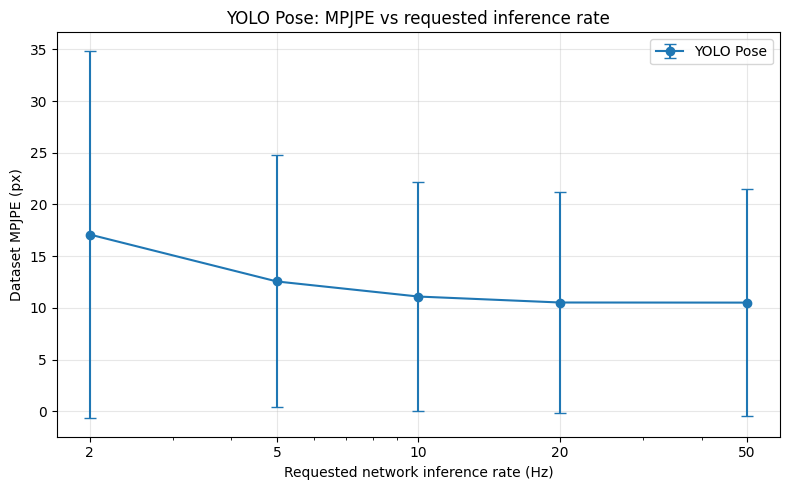

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_mpjpe_vs_detection_rate.png


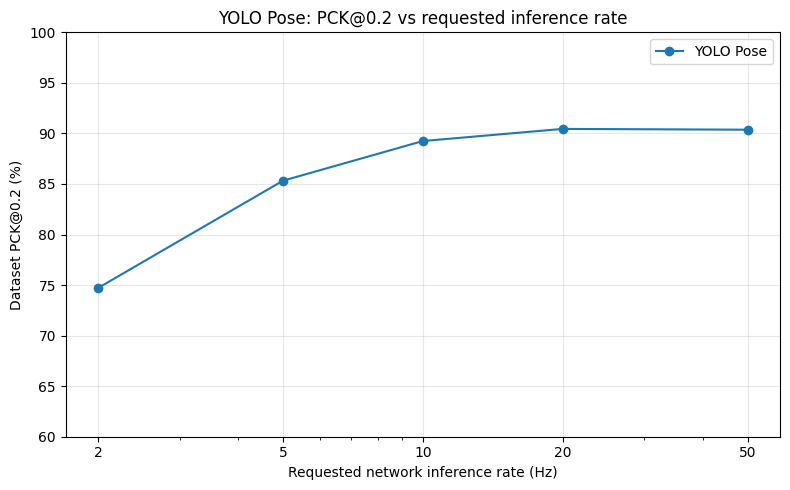

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_pck_0.2_vs_detection_rate.png


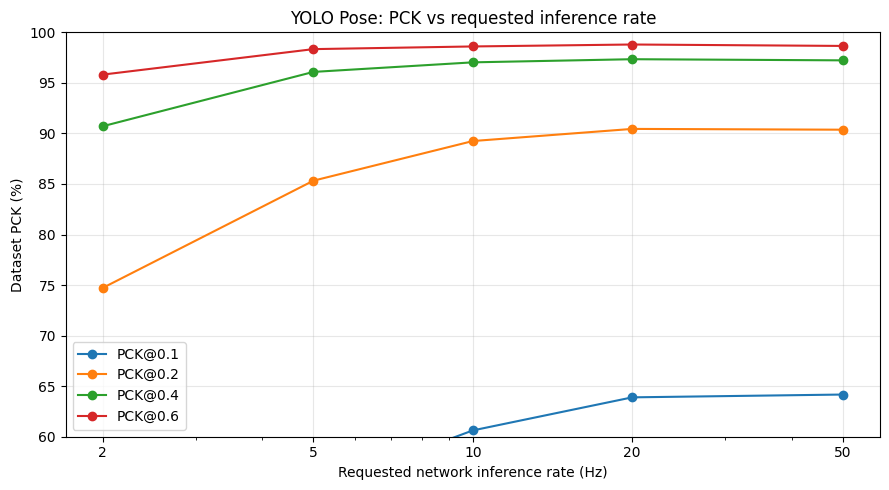

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_pck_all_thresholds.png


In [8]:
plot_metric(
    df_table,
    y_col='mpjpe_px',
    yerr_col='mpjpe_std_px',
    ylabel='Dataset MPJPE (px)',
    title='YOLO Pose: MPJPE vs requested inference rate',
    output_path=PLOTS_DIR / 'yolopose_mpjpe_vs_detection_rate.png',
)

PRIMARY_PCK_THRESHOLD = 0.2
primary_pck_col = f'pck_{PRIMARY_PCK_THRESHOLD:.1f}'

plot_metric(
    df_table,
    y_col=primary_pck_col,
    ylabel=f'Dataset PCK@{PRIMARY_PCK_THRESHOLD:.1f} (%)',
    title=f'YOLO Pose: PCK@{PRIMARY_PCK_THRESHOLD:.1f} vs requested inference rate',
    output_path=(
        PLOTS_DIR
        / f'yolopose_pck_{PRIMARY_PCK_THRESHOLD:.1f}_vs_detection_rate.png'
    ),
    ylim=(60, 100),
)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = df_table.sort_values('detection_rate_hz')
for threshold in PCK_THRESHOLDS:
    column = f'pck_{threshold:.1f}'
    ax.plot(
        plot_data['detection_rate_hz'],
        plot_data[column],
        marker='o',
        label=f'PCK@{threshold:.1f}',
    )
ax.set_xscale('log')
set_actual_x_ticks(ax, plot_data['detection_rate_hz'])
ax.set_xlabel('Requested network inference rate (Hz)')
ax.set_ylabel('Dataset PCK (%)')
ax.set_title('YOLO Pose: PCK vs requested inference rate')
ax.set_ylim(60, 100)
ax.legend()
plt.tight_layout()
pck_all_path = PLOTS_DIR / 'yolopose_pck_all_thresholds.png'
plt.savefig(pck_all_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', pck_all_path)


## Output-rate and latency diagnostics

The target output rate is `min(50 Hz, 1 / network_period)`. If the observed
curve remains close to 50 Hz for every requested period, the offline runner is
not applying `network_period` to the inference schedule.


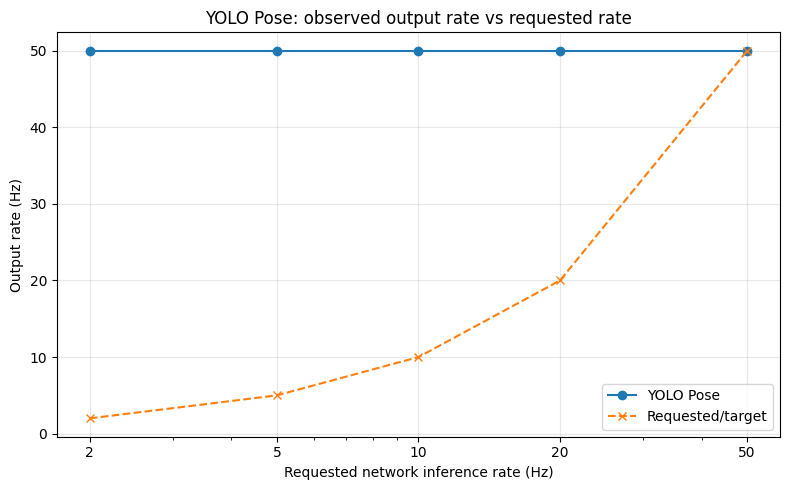

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_observed_vs_target_rate.png


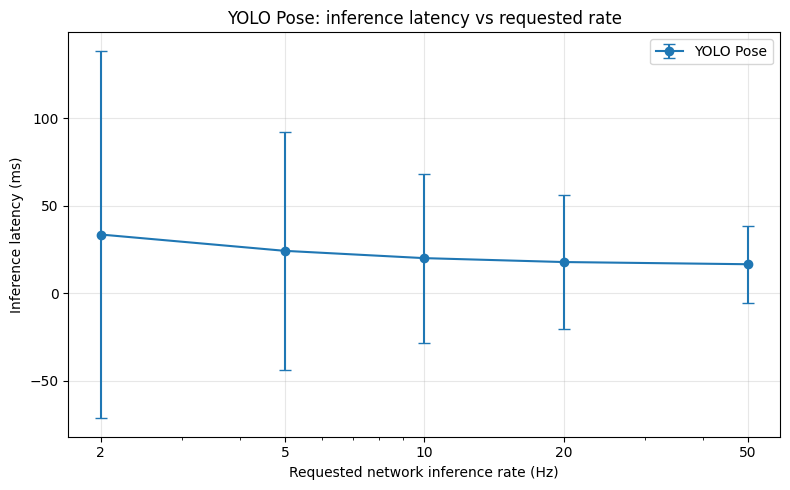

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_latency_vs_detection_rate.png


In [9]:
plot_metric(
    df_table,
    y_col='observed_output_rate_hz',
    reference_y_col='target_output_rate_hz',
    ylabel='Output rate (Hz)',
    title='YOLO Pose: observed output rate vs requested rate',
    output_path=PLOTS_DIR / 'yolopose_observed_vs_target_rate.png',
)

plot_metric(
    df_table,
    y_col='latency_mean_ms',
    yerr_col='latency_std_ms',
    ylabel='Inference latency (ms)',
    title='YOLO Pose: inference latency vs requested rate',
    output_path=PLOTS_DIR / 'yolopose_latency_vs_detection_rate.png',
)


## Dataset-level per-joint MPJPE and PCK


In [10]:
per_joint_rows = []

for period in sorted(df_seq['network_period_s'].unique()):
    subset = df_seq[np.isclose(df_seq['network_period_s'], period)]
    total_samples = int(subset['n_samples'].sum())

    for joint_name in joint_names:
        row = {
            'network_period_s': float(period),
            'detection_rate_hz': 1.0 / float(period),
            'joint': joint_name,
            'n_samples': total_samples,
            'mpjpe_px': (
                subset[f'sum_err_{joint_name}'].sum()
                / total_samples
            ),
        }

        for threshold in PCK_THRESHOLDS:
            pck_name = f'pck_{threshold:.1f}_{joint_name}'
            count_name = f'{pck_name}_correct_samples'
            row[f'pck_{threshold:.1f}'] = (
                subset[count_name].sum()
                / total_samples
                * 100.0
            )

        per_joint_rows.append(row)

df_joint = (
    pd.DataFrame(per_joint_rows)
    .sort_values(['network_period_s', 'joint'])
    .reset_index(drop=True)
)

per_joint_path = (
    SUMMARY_DIR / 'eh36m_yolopose_per_joint_dataset_metrics.csv'
)
df_joint.to_csv(per_joint_path, index=False)
print('Saved:', per_joint_path)
display(df_joint.head(20))


Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/results/summary/eh36m_yolopose_per_joint_dataset_metrics.csv


,network_period_s,detection_rate_hz,joint,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.02,50.0,ankle_left,245735,14.440162,45.435937,83.217694,95.080880,97.085071
1,0.02,50.0,ankle_right,245735,11.727855,60.497284,89.561926,96.069343,97.809429
2,0.02,50.0,elbow_left,245735,10.405337,69.633141,90.210593,97.304820,98.841028
3,0.02,50.0,elbow_right,245735,8.330707,77.726413,91.497345,97.841170,99.072985
4,0.02,50.0,head,245735,13.073445,33.946731,91.302012,99.124667,99.735080
5,0.02,50.0,hip_left,245735,11.323794,53.544265,91.118481,98.050746,99.240645
6,0.02,50.0,hip_right,245735,14.003124,24.759599,89.294565,97.910758,99.210125
7,0.02,50.0,knee_left,245735,10.655257,70.342035,91.437524,96.882007,98.531752
8,0.02,50.0,knee_right,245735,7.542980,82.960099,93.078316,97.651535,98.987527
9,0.02,50.0,shoulder_left,245735,6.888318,84.117444,95.412538,99.102285,99.680957


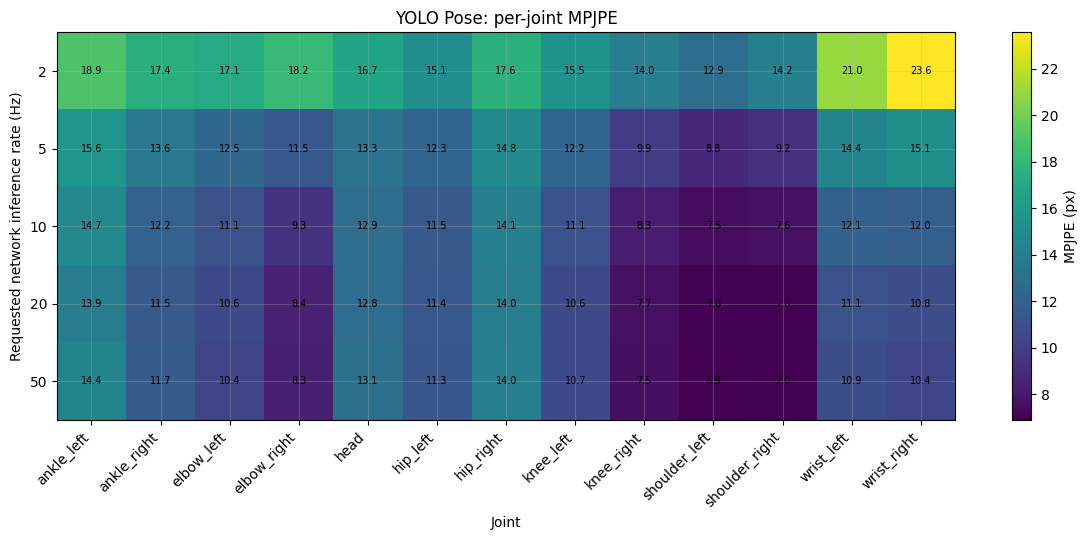

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_per_joint_mpjpe.png


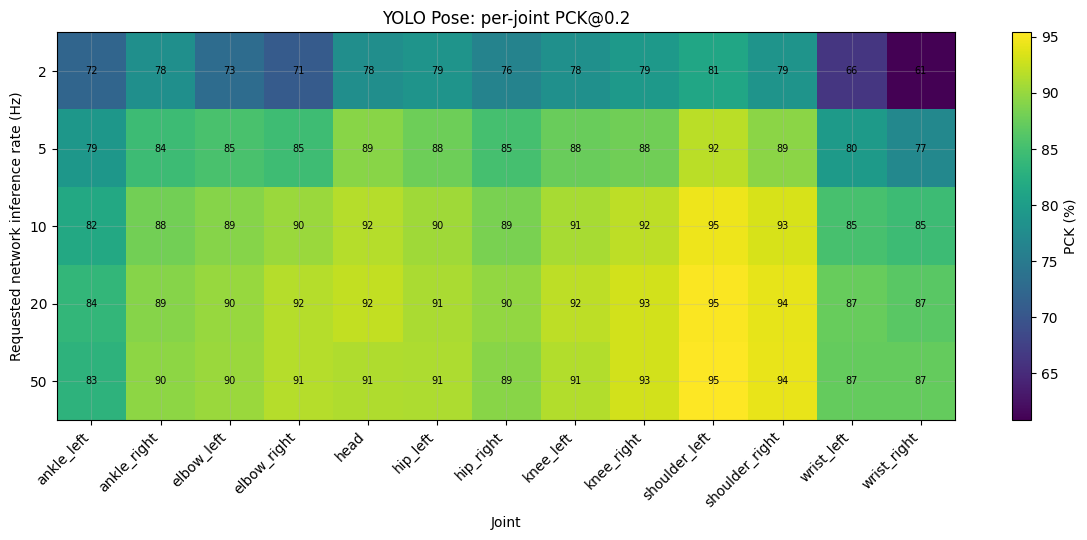

Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/yolopose_per_joint_pck_0.2.png


In [11]:
def joint_heatmap(table, value_col, title, colorbar_label, output_path, fmt):
    pivot = (
        table
        .pivot(index='detection_rate_hz', columns='joint', values=value_col)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5.5))
    image = ax.imshow(pivot.to_numpy(), aspect='auto')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f'{value:g}' for value in pivot.index])
    ax.set_xlabel('Joint')
    ax.set_ylabel('Requested network inference rate (Hz)')
    ax.set_title(title)

    for row_index in range(pivot.shape[0]):
        for column_index in range(pivot.shape[1]):
            value = pivot.iloc[row_index, column_index]
            if pd.notna(value):
                ax.text(
                    column_index,
                    row_index,
                    format(value, fmt),
                    ha='center',
                    va='center',
                    fontsize=7,
                )

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)


joint_heatmap(
    df_joint,
    value_col='mpjpe_px',
    title='YOLO Pose: per-joint MPJPE',
    colorbar_label='MPJPE (px)',
    output_path=PLOTS_DIR / 'yolopose_per_joint_mpjpe.png',
    fmt='.1f',
)

joint_heatmap(
    df_joint,
    value_col=primary_pck_col,
    title=f'YOLO Pose: per-joint PCK@{PRIMARY_PCK_THRESHOLD:.1f}',
    colorbar_label='PCK (%)',
    output_path=(
        PLOTS_DIR
        / f'yolopose_per_joint_pck_{PRIMARY_PCK_THRESHOLD:.1f}.png'
    ),
    fmt='.0f',
)


## Text summary and timing warnings


In [12]:
print('=' * 100)
print('YOLO POSE EXPERIMENT A — DATASET-WEIGHTED SUMMARY')
print('=' * 100)

for _, row in df_table.iterrows():
    print(
        f"\nperiod={row['network_period_s']:g}s "
        f"| requested={row['detection_rate_hz']:g}Hz"
    )
    print(
        f"  MPJPE: {row['mpjpe_px']:.3f} ± "
        f"{row['mpjpe_std_px']:.3f} px"
    )
    for threshold in PCK_THRESHOLDS:
        print(
            f"  PCK@{threshold:.1f}: "
            f"{row[f'pck_{threshold:.1f}']:.2f}%"
        )
    print(
        f"  latency: {row['latency_mean_ms']:.2f} ± "
        f"{row['latency_std_ms']:.2f} ms"
    )
    print(
        f"  output rate: observed={row['observed_output_rate_hz']:.2f}Hz "
        f"| target={row['target_output_rate_hz']:.2f}Hz"
    )
    print(
        f"  rate-compliant sequences: "
        f"{row['rate_compliance_pct']:.1f}%"
    )
    print(f"  approximate coverage: {row['coverage_pct']:.1f}%")
    print(
        f"  sequences={int(row['n_sequences'])} "
        f"| samples={int(row['n_samples'])}"
    )

    relative_error = abs(
        row['observed_output_rate_hz']
        - row['target_output_rate_hz']
    ) / row['target_output_rate_hz']

    if not np.isfinite(relative_error) or (
        relative_error > RATE_TOLERANCE_FRACTION
    ):
        print(
            '  WARNING: observed timestamps do not match the requested '
            'network period.'
        )

print('\nSummary CSVs:', SUMMARY_DIR)
print('Plots:', PLOTS_DIR)


YOLO POSE EXPERIMENT A — DATASET-WEIGHTED SUMMARY

period=0.02s | requested=50Hz
  MPJPE: 10.510 ± 10.980 px
  PCK@0.1: 64.17%
  PCK@0.2: 90.37%
  PCK@0.4: 97.23%
  PCK@0.6: 98.65%
  latency: 16.60 ± 22.05 ms
  output rate: observed=50.00Hz | target=50.00Hz
  rate-compliant sequences: 100.0%
  approximate coverage: 100.0%
  sequences=104 | samples=245735

period=0.05s | requested=20Hz
  MPJPE: 10.520 ± 10.662 px
  PCK@0.1: 63.89%
  PCK@0.2: 90.45%
  PCK@0.4: 97.34%
  PCK@0.6: 98.80%
  latency: 17.85 ± 38.46 ms
  output rate: observed=50.00Hz | target=20.00Hz
  rate-compliant sequences: 0.0%
  approximate coverage: 100.0%
  sequences=99 | samples=222787

period=0.1s | requested=10Hz
  MPJPE: 11.096 ± 11.071 px
  PCK@0.1: 60.62%
  PCK@0.2: 89.25%
  PCK@0.4: 97.03%
  PCK@0.6: 98.60%
  latency: 20.09 ± 48.24 ms
  output rate: observed=50.00Hz | target=10.00Hz
  rate-compliant sequences: 0.0%
  approximate coverage: 100.0%
  sequences=105 | samples=244902

period=0.2s | requested=5Hz
  MPJP

## Optional GT-versus-YOLO traces

The following cell creates one PDF page per joint for a selected sequence and
network period.


In [13]:
SELECTED_SEQUENCE = None
# Example: SELECTED_SEQUENCE = 'cam2_S9_Directions_1'
SELECTED_NETWORK_PERIOD = 0.05
TIME_START = None
TIME_END = None


available = df_seq[
    np.isclose(
        df_seq['network_period_s'],
        SELECTED_NETWORK_PERIOD,
    )
].copy()

if available.empty:
    raise RuntimeError(
        f'No rows for network period {SELECTED_NETWORK_PERIOD}'
    )

if SELECTED_SEQUENCE is None:
    SELECTED_SEQUENCE = sorted(available['sequence'].unique())[0]
    print('Using sequence:', SELECTED_SEQUENCE)

selected = available[available['sequence'] == SELECTED_SEQUENCE]
if len(selected) != 1:
    raise RuntimeError(
        f'Expected one row for {SELECTED_SEQUENCE}, found {len(selected)}'
    )

selected_row = selected.iloc[0]
ts_pred, latency_s, joints_pred = load_prediction_csv(
    Path(selected_row['csv_path'])
)
gt_data = ds_parsing.import_yarp_skeleton_data(
    Path(selected_row['gt_path']),
    multi_channel=False,
)
joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

valid = (
    np.isfinite(ts_pred)
    & np.isfinite(joints_pred).all(axis=(1, 2))
    & np.isfinite(joints_gt).all(axis=(1, 2))
)
if ZERO_POSE_IS_MISSING:
    valid &= np.any(np.abs(joints_pred) > 1e-9, axis=(1, 2))

ts_pred = ts_pred[valid]
joints_pred = joints_pred[valid]
joints_gt = joints_gt[valid]

time_mask = np.ones_like(ts_pred, dtype=bool)
if TIME_START is not None:
    time_mask &= ts_pred >= TIME_START
if TIME_END is not None:
    time_mask &= ts_pred <= TIME_END

ts_plot = ts_pred[time_mask]
pred_plot = joints_pred[time_mask]
gt_plot = joints_gt[time_mask]

period_tag = str(SELECTED_NETWORK_PERIOD).replace('.', 'p')
trace_path = (
    PLOTS_DIR
    / f'{SELECTED_SEQUENCE}_yolopose_np_{period_tag}_traces.pdf'
)

with PdfPages(trace_path) as pdf:
    for joint_index, joint_name in enumerate(joint_names):
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(ts_plot, gt_plot[:, joint_index, 0], label='GT x')
        ax.plot(ts_plot, pred_plot[:, joint_index, 0], label='YOLO x')
        ax.plot(
            ts_plot,
            gt_plot[:, joint_index, 1],
            linestyle='--',
            label='GT y',
        )
        ax.plot(
            ts_plot,
            pred_plot[:, joint_index, 1],
            linestyle='--',
            label='YOLO y',
        )
        ax.set_xlabel('Timestamp (s)')
        ax.set_ylabel('Coordinate (px)')
        ax.set_title(
            f'{SELECTED_SEQUENCE} — {joint_name} '
            f'(period {SELECTED_NETWORK_PERIOD:g}s)'
        )
        ax.legend(ncol=4)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print('Saved:', trace_path)


Using sequence: cam2_S11_Directions


Saved: /workspace/moveEnetFlow/experiments/ExpA/YOLO_expA_accuracy_vs_network_period/h36m_full_test/plots/cam2_S11_Directions_yolopose_np_0p05_traces.pdf
